In [1]:
import pandas as pd

In [2]:
#temizlenmiş verilerin tutulduğu csv-yi okuyalım
tumVeriler = pd.read_csv("temizlenmis_veri.csv", encoding="cp1254") #kullanılan veri temizlenmiş olmalı veritemizleme dosyası ile önce veri temizlenmeli
print(tumVeriler)

                                           temiz_veri
0                  bazen hayat gerçekten hızlı akıyor
1           bazen hayat gerçekten karmaşık olabiliyor
2   bazen hayat kadar karmaşık geliyor yapacağımı ...
3   bazen insanlar gerçekten garip davranabiliyor ...
4   bazen küçük hatalar bile büyük sorunlara yol a...
5   bazen küçük şeyler insanı gerçekten mutlu edeb...
6             böyle bir başarı elde etmek kolay değil
7              böyle bir fırsatı kaçırmak istemiyorum
8   böyle bir fırsatın karşıma çıkması beni heyeca...
9   böyle bir fırsatın karşıma çıkması beni gerçek...
10  böyle güzel bir başarı elde etmek beni mutlu etti
11      böyle güzel bir gün geçirmek gerçekten harika
12        böyle güzel bir haber almak beni sevindirdi
13  böyle güzel bir haber almak bütün günümü değiş...
14  böyle güzel bir haber almak gerçekten sevindirici
15  böyle güzel bir manzara karşısında insan gerçe...
16  akşam arkadaşlarımla güzel bir akşam yemeği pl...
17         durum beni biraz 

In [53]:
import pandas as pd
from nayalex_tr import NAYALex

rows = []

for i in range(len(tumVeriler)):
    veri_text = tumVeriler.loc[i]['temiz_veri']

    text_object = NAYALex(veri_text)
    frekans = text_object.affect_frequencies

    row = {
        "texti": veri_text,
        "olumlu": round(frekans['olumlu'],2),
        "olumsuz": round(frekans['olumsuz'],2),
        "iyimserlik": round(frekans['iyimserlik'],2),
        "umut": round(frekans['umut'],2),
        "kaygı": round(frekans['kaygı'],2),
        "sevgi": round(frekans['sevgi'],2),
        "suçluluk": round(frekans['suçluluk'],2),
        "kader": round(frekans['kader'],2),
        "teslimiyet": round(frekans['teslimiyet'],2),
        "merak": round(frekans['merak'],2),
        "duygusallık": round(frekans['duygusallık'],2),
        "huşu": round(frekans['huşu'],2),
        "umutsuzluk": round(frekans['umutsuzluk'],2),
        "utanç": round(frekans['utanç'],2),
        "onaylamama": round(frekans['onaylamama'],2),
        "inançsızlık": round(frekans['inançsızlık'],2),
        "öfke-nefret": round(frekans['öfke-nefret'],2),
        "pişmanlık": round(frekans['pişmanlık'],2),
        "kıskançlık": round(frekans['kıskançlık'],2),
        "karamsarlık": round(frekans['karamsarlık'],2),
        "küçümseme": round(frekans['küçümseme'],2),
        "alaycılık": round(frekans['alaycılık'],2),
        "kötülük": round(frekans['kötülük'],2),
        "saldırganlık": round(frekans['saldırganlık'],2),
        "gurur": round(frekans['gurur'],2),
        "hakimiyet": round(frekans['hakimiyet'],2),
        "acı-tatlılık": round(frekans['acı-tatlılık'],2),
        "kararsızlık": round(frekans['kararsızlık'],2),
        "donukluk": round(frekans['donukluk'],2),
        "bilinç bulanıklığı": round(frekans['bilinç bulanıklığı'],2),
        "öfke": round(frekans['öfke'],2),
        "beklenti": round(frekans['beklenti'],2),
        "tiksinti": round(frekans['tiksinti'],2),
        "korku": round(frekans['korku'],2),
        "sevinç": round(frekans['sevinç'],2),
        "üzüntü": round(frekans['üzüntü'],2),
        "sürpriz": round(frekans['sürpriz'],2),
        "güven": round(frekans['güven'],2)
    }

    rows.append(row)

df = pd.DataFrame(rows)

# istenilen sütun sırası(buradaki kelimelr NAYALex sözlüğündeki duygular)
columns_order = [
"texti","olumlu","olumsuz","iyimserlik","umut","kaygı","sevgi","suçluluk","kader",
"teslimiyet","merak","duygusallık","huşu","umutsuzluk","utanç","onaylamama",
"inançsızlık","öfke-nefret","pişmanlık","kıskançlık","karamsarlık","küçümseme",
"alaycılık","kötülük","saldırganlık","gurur","hakimiyet","acı-tatlılık",
"kararsızlık","donukluk","bilinç bulanıklığı","öfke","beklenti","tiksinti",
"korku","sevinç","üzüntü","sürpriz","güven"
]

df = df[columns_order]

df.to_csv("naya_sonuc.csv", index=False, encoding="cp1254")

print("Duygu değerleri işlenmiş CSV dosyası başarıyla oluşturuldu")
print("Oluşturulan naya_sonuc.csv dosyasında her veri için duygu karşılıkları bulunmaktadır. farklı programlarda analiz edilebilir.")
print("Aşağıda burada yapılabilecek bazı testler yapılmıştır. ")

Duygu değerleriişlenmiş CSV dosyası başarıyla oluşturuldu
Oluşturulan naya_sonuc.csv dosyası farklı programlarda analiz edilebilir.
Aşağıda burada yapılabilecek bazı testler yapılmıştır. 


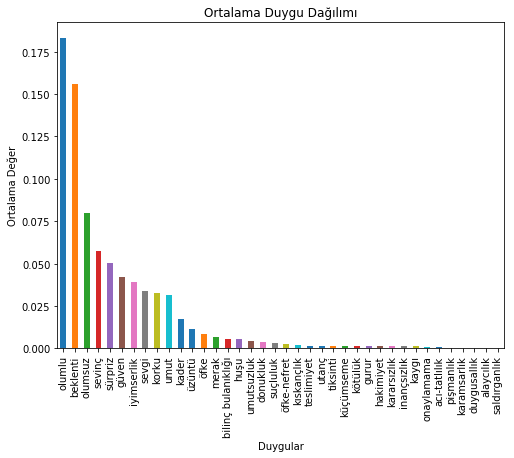

In [54]:
#Ortalama Duygu Dağılımı (Bar Chart)
#Dataset içindeki ortalama duygu değerlerini gösterir.
import matplotlib.pyplot as plt

# text sütunu hariç
emotion_means = df.drop(columns=["texti"]).mean()

plt.figure(figsize=(8,6))
emotion_means.sort_values(ascending=False).plot(kind="bar")

plt.title("Ortalama Duygu Dağılımı")
plt.xlabel("Duygular")
plt.ylabel("Ortalama Değer")

plt.xticks(rotation=90)
plt.show()

#Bu grafik sana şunu gösterir:
#veri setinde en baskın duygular
#genel duygu profili

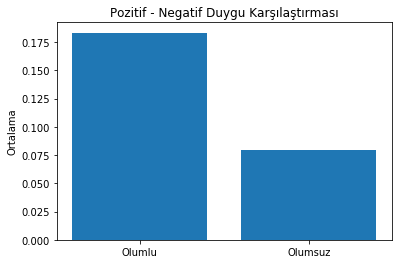

In [55]:
#Pozitif vs Negatif Duygu Grafiği
plt.figure(figsize=(6,4))

labels = ["Olumlu", "Olumsuz"]
values = [df["olumlu"].mean(), df["olumsuz"].mean()]

plt.bar(labels, values)

plt.title("Pozitif - Negatif Duygu Karşılaştırması")
plt.ylabel("Ortalama")

plt.show()

#Bu grafik: dataset genel olarak pozitif mi negatif mi gösterir.

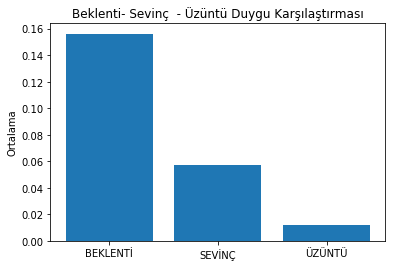

In [56]:
#Beklenti, Sevinç üzüntü Duygu Grafiği
#burada istenilen duygular seçilerek farklı senaryolar üretilebilir
plt.figure(figsize=(6,4))

labels = ["BEKLENTİ","SEVİNÇ", "ÜZÜNTÜ"]
values = [df["beklenti"].mean(), df["sevinç"].mean(), df["üzüntü"].mean()]

plt.bar(labels, values)

plt.title("Beklenti- Sevinç  - Üzüntü Duygu Karşılaştırması")
plt.ylabel("Ortalama")

plt.show()
#Bu grafik: dataset genel olarak Beklenti- Sevinç  - Üzüntü Duygu durumlarını gösterir.

Text(0.5,1,'Duygu Korelasyon Heatmap')

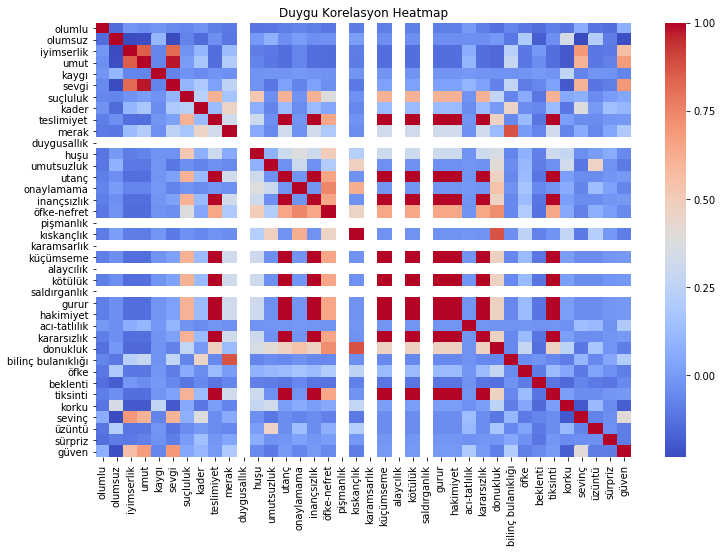

In [57]:
#Duygu Heatmap
import seaborn as sns

plt.figure(figsize=(12,8))

sns.heatmap(df.drop(columns=["texti"]).corr(), cmap="coolwarm")

plt.title("Duygu Korelasyon Heatmap")

#Bu grafik :hangi duygular birlikte oluşuyor, hangi duygular zıt

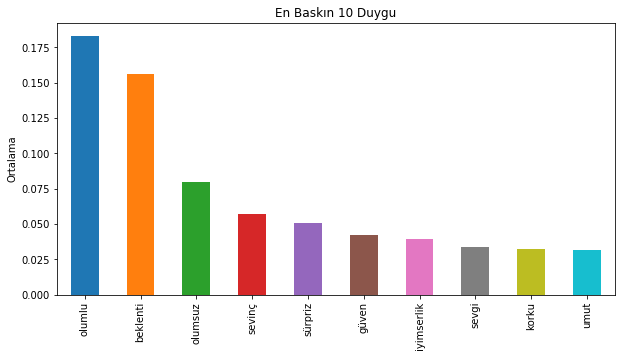

In [58]:
#En Çok Görülen 10 Duygu
top_emotions = emotion_means.sort_values(ascending=False).head(10) 
#head(10) 10 değeri değiştirilerek örneğin head(5) En Çok Görülen 5 Duygu 

plt.figure(figsize=(10,5))
top_emotions.plot(kind="bar")

plt.title("En Baskın 10 Duygu")
plt.ylabel("Ortalama")

plt.show()

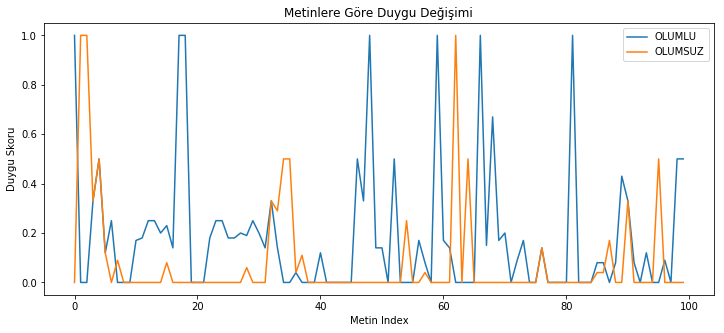

In [59]:
#Metin Başına Duygu Dağılımı
plt.figure(figsize=(12,5))

plt.plot(df["olumlu"], label="OLUMLU") #etiketler değiştirilerek farklı grafikler elde edilebilir
plt.plot(df["olumsuz"], label="OLUMSUZ")#

plt.legend()
plt.title("Metinlere Göre Duygu Değişimi")
plt.xlabel("Metin Index")
plt.ylabel("Duygu Skoru")

plt.show()

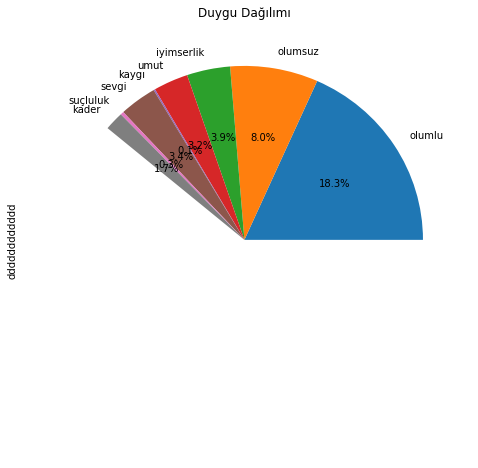

In [60]:
#Pie Chart (Genel duygu dağılımı)
emotion_means = df.drop(columns=["texti"]).mean()

plt.figure(figsize=(8,8))

emotion_means.head(8).plot(
    kind="pie",
    autopct='%1.1f%%'
)

plt.title("Duygu Dağılımı")
plt.ylabel("dddddddddddd")

plt.show()

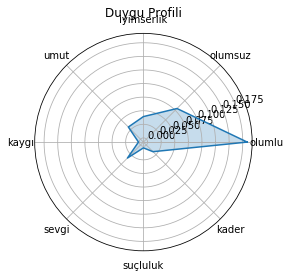

In [43]:
#Radar Chart 

#Ortalama duyguları radar grafikte göstermek.

import numpy as np

labels = duygu_ort.index[:8] #[:8] değeri değiştrilerekfarklı sayıda duygu ile grafik elde edilebilir.
values = duygu_ort.values[:8]# labels ve values [:8] değerleri aynı olmalı ör [:4] [:4]

angles = np.linspace(0, 2*np.pi, len(labels), endpoint=False)

values = np.concatenate((values,[values[0]]))
angles = np.concatenate((angles,[angles[0]]))

fig = plt.figure()
ax = fig.add_subplot(111, polar=True)

ax.plot(angles, values)
ax.fill(angles, values, alpha=0.25)

ax.set_thetagrids(angles*180/np.pi, labels)

plt.title("Duygu Profili")
plt.show()